In [15]:
print("Project Started")

Project Started


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("../data/Suicides in India 2001-2012.csv")

In [19]:
df.head()


,State,Year,Type_code,Type,Gender,Age_group,Total
0,A & N Islands,2001,Causes,Illness (Aids/STD),Female,0-14,0
1,A & N Islands,2001,Causes,Bankruptcy or Sudden change in Economic,Female,0-14,0
2,A & N Islands,2001,Causes,Cancellation/Non-Settlement of Marriage,Female,0-14,0
3,A & N Islands,2001,Causes,Physical Abuse (Rape/Incest Etc.),Female,0-14,0
4,A & N Islands,2001,Causes,Dowry Dispute,Female,0-14,0


In [20]:
df.shape

(237519, 7)

In [21]:
df.columns

Index(['State', 'Year', 'Type_code', 'Type', 'Gender', 'Age_group', 'Total'], dtype='str')

In [22]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 237519 entries, 0 to 237518
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   State      237519 non-null  str  
 1   Year       237519 non-null  int64
 2   Type_code  237519 non-null  str  
 3   Type       237519 non-null  str  
 4   Gender     237519 non-null  str  
 5   Age_group  237519 non-null  str  
 6   Total      237519 non-null  int64
dtypes: int64(2), str(5)
memory usage: 12.7 MB


In [23]:
df.isnull().sum()

State        0
Year         0
Type_code    0
Type         0
Gender       0
Age_group    0
Total        0
dtype: int64

In [24]:
df.describe()

,Year,Total
count,237519.000000,237519.000000
mean,2006.500448,55.034477
std,3.452240,792.749038
min,2001.000000,0.000000
25%,2004.000000,0.000000
50%,2007.000000,0.000000
75%,2010.000000,6.000000
max,2012.000000,63343.000000


In [25]:
df.head()

,State,Year,Type_code,Type,Gender,Age_group,Total
0,A & N Islands,2001,Causes,Illness (Aids/STD),Female,0-14,0
1,A & N Islands,2001,Causes,Bankruptcy or Sudden change in Economic,Female,0-14,0
2,A & N Islands,2001,Causes,Cancellation/Non-Settlement of Marriage,Female,0-14,0
3,A & N Islands,2001,Causes,Physical Abuse (Rape/Incest Etc.),Female,0-14,0
4,A & N Islands,2001,Causes,Dowry Dispute,Female,0-14,0


In [26]:
total_cases = df['Total'].sum()

print("Total Suicide Cases in India:", total_cases)

Total Suicide Cases in India: 13071734


In [27]:
state_data = df.groupby('State')['Total'].sum().sort_values(ascending=False)

state_data.head(10)

State
Total (All India)    2911862
Total (States)       2858026
Maharashtra           901945
West Bengal           849936
Tamil Nadu            818691
Andhra Pradesh        814059
Karnataka             734825
Kerala                538946
Madhya Pradesh        451535
Gujarat               330858
Name: Total, dtype: int64

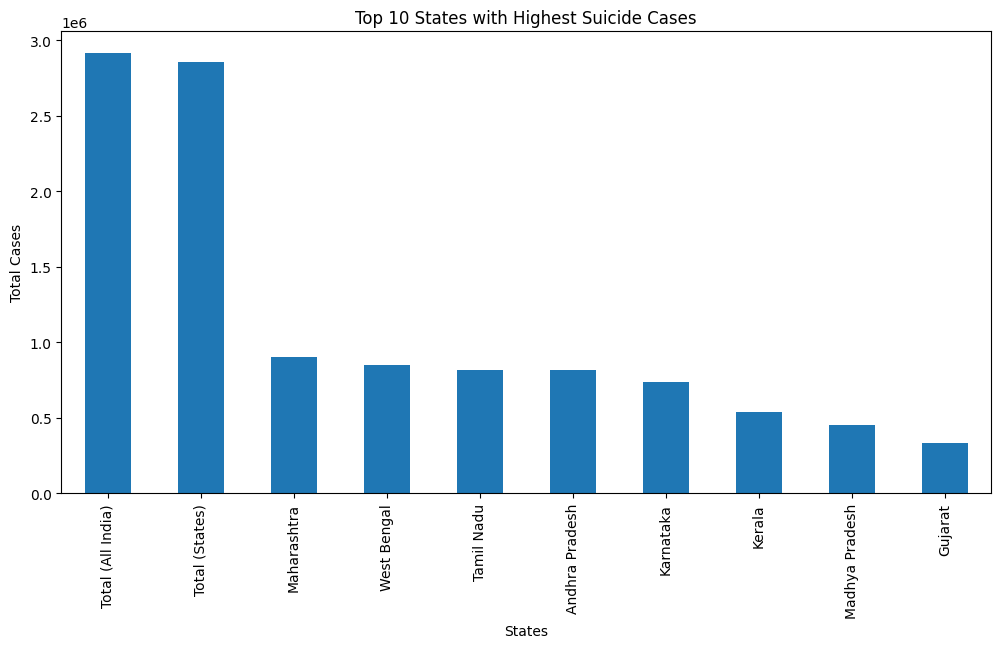

In [28]:
plt.figure(figsize=(12,6))

state_data.head(10).plot(kind='bar')

plt.title("Top 10 States with Highest Suicide Cases")
plt.xlabel("States")
plt.ylabel("Total Cases")

plt.show()

In [29]:
year_data = df.groupby('Year')['Total'].sum()

year_data

Year
2001     976464
2002     993648
2003     997622
2004    1023137
2005    1025201
2006    1062991
2007    1103667
2008    1125082
2009    1144033
2010    1211322
2011    1219499
2012    1189068
Name: Total, dtype: int64

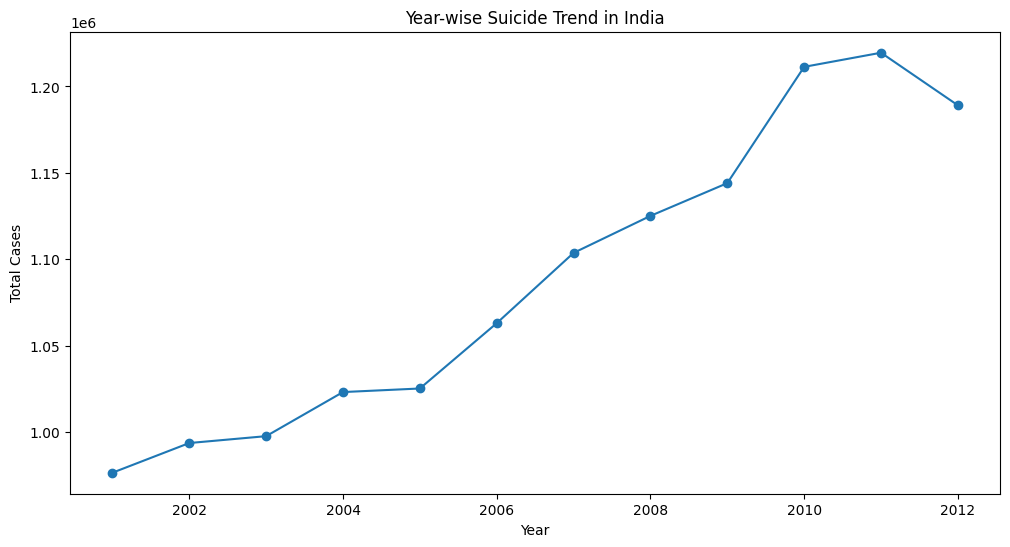

In [30]:
plt.figure(figsize=(12,6))

year_data.plot(marker='o')

plt.title("Year-wise Suicide Trend in India")
plt.xlabel("Year")
plt.ylabel("Total Cases")

plt.show()

In [31]:
gender_data = df.groupby('Gender')['Total'].sum()

gender_data

Gender
Female    4702974
Male      8368760
Name: Total, dtype: int64

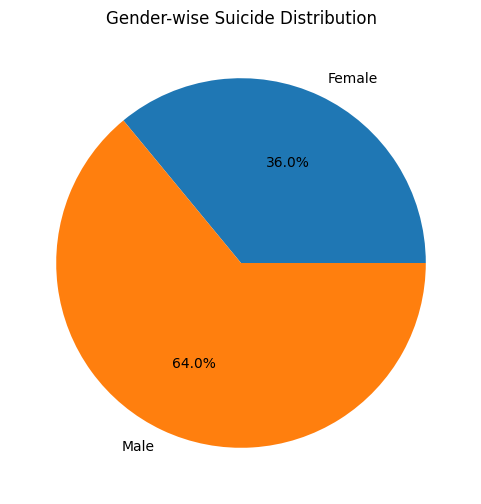

In [32]:
plt.figure(figsize=(6,6))

plt.pie(gender_data,
        labels=gender_data.index,
        autopct='%1.1f%%')

plt.title("Gender-wise Suicide Distribution")

plt.show()

In [33]:
age_data = df.groupby('Age_group')['Total'].sum().sort_values(ascending=False)

age_data

Age_group
0-100+    8735586
15-29     1534037
30-44     1471599
45-59      885177
60+        346925
0-14        98410
Name: Total, dtype: int64

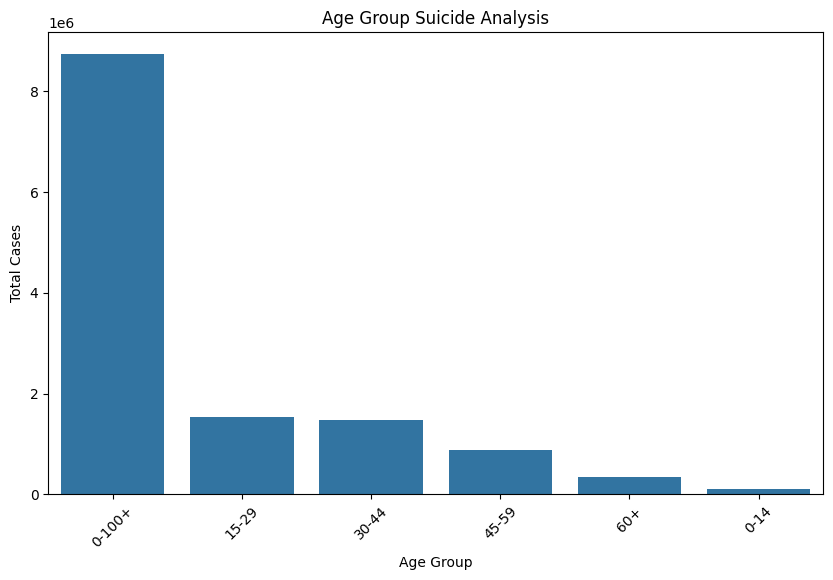

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(x=age_data.index,
            y=age_data.values)

plt.xticks(rotation=45)

plt.title("Age Group Suicide Analysis")
plt.xlabel("Age Group")
plt.ylabel("Total Cases")

plt.show()

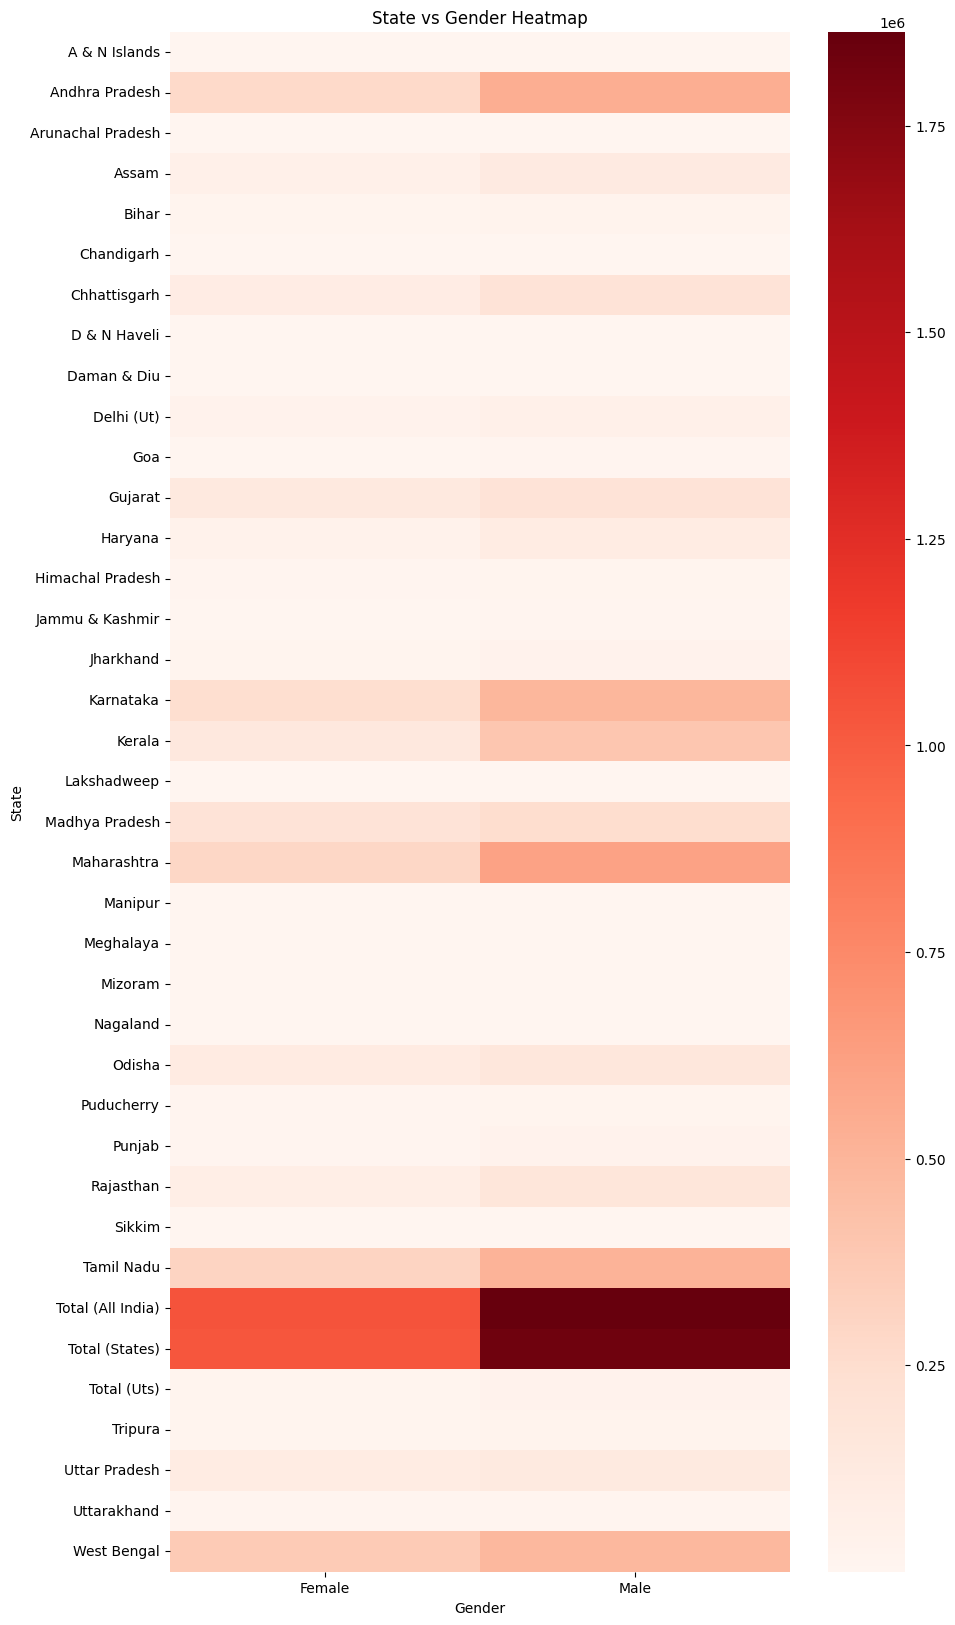

In [35]:
pivot_table = df.pivot_table(values='Total',
                             index='State',
                             columns='Gender',
                             aggfunc='sum')

plt.figure(figsize=(10,20))

sns.heatmap(pivot_table,
            cmap='Reds')

plt.title("State vs Gender Heatmap")

plt.show()

Insights:

1. Some states have significantly higher suicide rates.
2. Male suicide percentage is higher than female.
3. Young and middle-age groups are more affected.
4. Suicide trends vary across years.
5. Regional patterns are visible through heatmaps.